### Isolation forest is one the more advanced outlier detection/removal algorithms

Unlike IQR and Z-score -approaches, Isolation Forest is actually a machine learning algorithm, which will also remove outliers and (and partially noise) within the distribution itself.

### NOTE: remember to change the variables when you inspect outliers/noise

In [67]:
# can process the whole dataset 
# and compares variables to each other instead
# of focusing on outliers on a single variable
from sklearn.ensemble import IsolationForest
import pandas as pd

# adjust the contamination rate as you see fit
# for example, if you expect 5% of the data to be outliers
# you can use 0.05 etc. 

# basically, this is how aggressive Isolation Forest will be
# increase if you think you need to detect more outliers
# decrease if you need less outliers
iso = IsolationForest(contamination=0.05) 
df = pd.read_csv("../lifestyle_sustainability_data_processed.csv")

# REMEMBER! Isolation Forest is a machine learning algorithm
# => ALL VARIABLES HAVE TO BE NUMERIC AT THIS POINT

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

Inliers: 474
Outliers: 25


#### It's usually easier to see if we removed enough or too much by visualizing!

In [68]:
df

,Age,LocalFoodFrequency,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,UsingPlasticProducts,...,EnergySource_Mixed,EnergySource_Non-Renewable,HomeType_Apartment,HomeType_House,Gender_Female,Gender_Male,Gender_Non-Binary,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill
0,35,2,800,0,1,5,2.0,100,1500,1,...,0,0,1,0,1,0,0,0,1,0
1,28,1,1500,1,1,4,1.0,250,3000,2,...,1,0,0,1,0,1,0,0,0,0
2,65,0,2500,2,0,2,0.0,400,4500,3,...,0,1,0,1,0,1,0,0,0,1
3,42,2,950,1,1,4,1.0,150,2000,1,...,0,0,1,0,1,0,0,0,0,0
4,31,1,1800,2,1,3,0.0,300,3500,2,...,1,0,0,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,38,2,1789,1,1,4,2.0,150,2000,1,...,0,0,0,1,1,0,0,0,0,0
495,25,1,987,2,0,2,0.0,400,4500,3,...,0,1,1,0,0,1,0,0,0,1
496,51,3,1678,0,1,5,2.0,280,3200,2,...,1,0,0,1,0,0,1,0,0,0
497,32,0,1850,2,0,1,2.0,397,4076,1,...,1,0,0,1,1,0,0,0,0,0


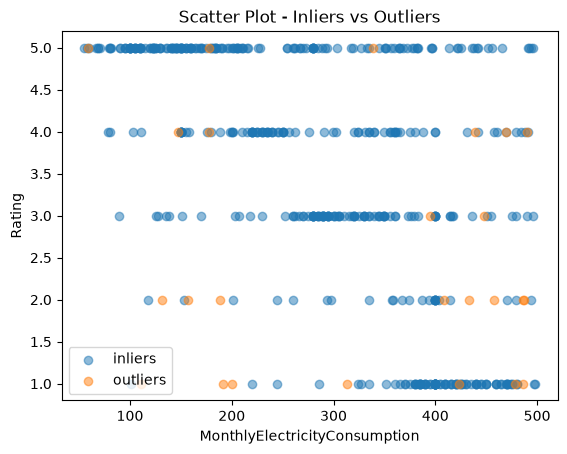

In [69]:
import matplotlib.pyplot as plt

# change the variable if you want to inspect this from other point of views
variable = "MonthlyElectricityConsumption"
target = "Rating"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
# inliers_sample = inliers.sample(3000)
# outliers_sample = outliers.sample(100)
inliers_sample = inliers
outliers_sample = outliers

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

In [70]:
outliers

,Age,LocalFoodFrequency,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,UsingPlasticProducts,...,EnergySource_Mixed,EnergySource_Non-Renewable,HomeType_Apartment,HomeType_House,Gender_Female,Gender_Male,Gender_Non-Binary,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill
220,57,0,2742,3,0,2,0.0,131,571,1,...,1,0,0,1,0,0,1,0,0,1
230,51,2,1995,3,1,2,2.0,409,4638,3,...,0,0,1,0,0,1,0,1,0,0
241,24,0,1547,1,0,5,2.0,178,4870,0,...,0,1,0,1,0,0,1,0,1,0
246,18,3,607,0,0,2,0.0,395,617,3,...,1,0,1,0,0,0,1,0,0,0
253,30,1,2850,2,0,1,2.0,486,1055,3,...,0,1,0,1,0,0,1,0,0,0
260,75,0,2766,2,1,3,2.0,188,4923,1,...,0,1,1,0,1,0,0,0,0,1
272,63,3,2815,2,0,1,2.0,487,4424,0,...,1,0,0,1,1,0,0,0,1,0
275,48,2,2445,2,1,5,0.0,178,1936,3,...,0,0,1,0,0,0,1,1,0,0
277,74,2,837,1,0,2,0.0,448,2078,2,...,0,1,1,0,0,0,0,0,1,0
298,57,1,2064,2,0,1,NaN,200,2419,2,...,1,0,0,0,0,1,0,1,0,0


### Another popular alternative: Elliptic Envelope

In [71]:
from sklearn.covariance import EllipticEnvelope

# contamination, same thing as in isolation
ee = EllipticEnvelope(contamination=0.05)
df = pd.read_csv("../lifestyle_sustainability_data_processed.csv")


# handle these better with your own dataset, here we are simply dropping these
df = df.dropna()

y_pred = ee.fit_predict(df)
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

# Add outlier
df["outlier"] = y_pred == -1


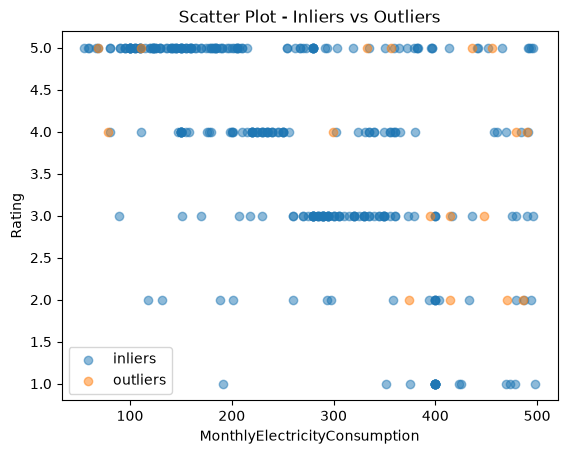

In [72]:
import matplotlib.pyplot as plt

variable = "MonthlyElectricityConsumption"
target = "Rating"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
# inliers_sample = inliers.sample(3000)
# outliers_sample = outliers.sample(100)
inliers_sample = inliers
outliers_sample = outliers

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

In [73]:
outliers

,Age,LocalFoodFrequency,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,UsingPlasticProducts,...,EnergySource_Mixed,EnergySource_Non-Renewable,HomeType_Apartment,HomeType_House,Gender_Female,Gender_Male,Gender_Non-Binary,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill
246,18,3,607,0,0,2,0.0,395,617,3,...,1,0,1,0,0,0,1,0,0,0
257,31,1,1682,2,1,1,1.0,414,1745,1,...,0,1,0,1,0,1,0,0,0,0
261,39,3,1544,1,0,2,1.0,470,2771,1,...,0,1,0,0,0,0,0,1,0,0
266,71,0,599,1,0,4,2.0,374,1429,0,...,0,0,0,0,1,0,0,0,1,0
267,64,2,590,2,1,5,1.0,78,4035,3,...,1,0,0,1,0,0,1,0,0,1
277,74,2,837,1,0,2,0.0,448,2078,2,...,0,1,1,0,0,0,0,0,1,0
292,28,1,1978,0,1,5,0.0,69,3579,2,...,1,0,0,0,1,0,0,0,0,1
296,54,3,2988,2,0,3,1.0,414,689,0,...,0,0,0,1,1,0,0,0,0,1
307,31,1,2160,0,0,2,1.0,486,1168,0,...,0,1,0,0,0,0,0,0,1,0
309,63,3,2204,3,1,5,1.0,436,2190,1,...,0,1,0,0,0,0,0,0,0,0


## EXTRA - if you wish to visualize multiple variables with pairplot

**However, this gets pretty difficult to read easily.**

In [74]:
# uncomment the code if you wish to 

# # Visualize
# import seaborn as sns

# # this also takes time with larger datasets
# sns.pairplot(
#     df,
#     vars=df.columns.drop("outlier"),
#     hue="outlier",
#     diag_kind="hist",
#     plot_kws={"alpha": 0.5}
# )

# plt.show()